# サブエージェントとエージェント・アズ・ア・ツール

このノートブックでは、架空のショッピングモール「スターライトテラス」の案内カウンターの AI エージェントで、サブエージェントの使い方を学びます。

あわせて、エージェント・アズ・ア・ツールの仕組みも解説します。

## 事前準備

**[SAT-01]**

ADK と Gemini API の利用に必要なパッケージをインストールします。

ADK は開発の速度が速く、後方互換性のない機能変更が行われることがあります。ここでは、安全のために動作確認ができたバーションを指定してインストールしています。

**最後に `RESTART SESSION` ボタンが表示された場合は、これをクリックしてセッションを再起動してください。**

**注意**: `ERROR: pip's dependency resolver does not currently take into account...` のようなエラーメッセージが表示される場合がありますが、これは無視して構いません。

In [ ]:
%pip install --upgrade --user \
    google-adk==2.8.0 \
    google-cloud-aiplatform==2.0.1 \
    google-genai==2.20.0 \
    vl-convert-python==1.9.0.post1

**[SAT-02]**

インストールされたパッケージのバージョンを確認します。

In [1]:
!pip list | grep -E "(google-adk|google-genai|google-cloud-aiplatform|vl-convert-python)"

google-adk                            2.8.0
google-cloud-aiplatform               2.0.1
google-genai                          2.20.0
vl-convert-python                     1.9.0.post1


下記の内容が出力されたことを確認してください。

```
google-adk                               2.8.0
google-cloud-aiplatform                  2.0.1
google-genai                             2.20.0
vl-convert-python                        1.9.0.post1
```

## ユーザー認証

**[SAT-03]**

変数 `PROJECT_ID` に事前に準備したプロジェクトのプロジェクト ID を指定してください。

**注意**: プロジェクトを作成したユーザーアカウントと Colab を使用中のユーザーアカウントが一致している必要があります。


In [ ]:
###
PROJECT_ID = 'Project ID を入力'
###

if (not PROJECT_ID) or PROJECT_ID == 'Project ID を入力':
    print('Gemini API を使用する Google Cloud Project の Project ID を入力してください。')
else:
    print(f'変数 PROJECT_ID を設定しました。')
    print(f'PROJECT_ID = {PROJECT_ID}')

**[SAT-04]**

Google Cloud のプロジェクトを使用するためのユーザー認証を行います。

ポップアップ画面の指示に従って、認証処理を行ってください。

許可する操作を選択するチェックボックスが表示された場合は、すべてにチェックを入れてください。

In [3]:
from google.colab import auth
auth.authenticate_user(project_id=PROJECT_ID)

## 初期設定

**[SAT-05]**

この後の作業に必要なモジュールをインポートして、LlmAgent オブジェクトが参照する環境変数を設定します。

In [8]:
import json, os, urllib, uuid
import vl_convert as vlc
from IPython.display import Markdown, display
import agentplatform
from agentplatform.frameworks import AdkApp
from google.adk.agents.llm_agent import LlmAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.tools import ToolContext
from google.adk.tools.agent_tool import AgentTool
from google.genai.types import Part

agentplatform.init(project=PROJECT_ID, location='us-central1')
os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
os.environ['GOOGLE_CLOUD_LOCATION'] = 'global'
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'True'

**[SAT-06]**

AdkApp オブジェクトとの会話を行う簡易的なアプリケーションのクラス ChatClient を定義します。

In [5]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = session['id']

        result = []
        events = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            events.append(event)
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    result.append(response)
        return '\n'.join(result), events

## LlmAgent オブジェクトと AdkApp オブジェクトの作成

**[SAT-07]**

「テラスガイド」と「とばりちゃん」が参照するお店の情報を定義します。

In [ ]:
shopping_mall_info = '''
* 名称: スターライトテラス

* 立地と外観:
  - 新宿駅南口から徒歩5分。賑やかな駅周辺から少し離れ、落ち着いた雰囲気のエリアに位置しています。
  - 緑豊かなオープンテラスが特徴的で、都会の中にありながらも自然を感じられる空間を提供しています。
  - 夜になると、間接照明が灯り、ロマンチックな雰囲気に包まれます。

* イベント:
  - 週末には、ジャズライブやアコースティックライブなどの音楽イベントがテラスで開催され、夜の雰囲気を盛り上げます。
  - 季節ごとのイルミネーションが美しく、訪れる人の目を楽しませます。
  - 地域住民向けのワークショップやマルシェなども開催され、地域との交流を深めています。

* テナント:
  - 個性的なセレクトショップ: 大手チェーン店だけでなく、オーナーのこだわりが詰まった隠れ家のようなセレクトショップが点在しています。
  - こだわりのレストランやカフェ: 「夜の帳」のように、落ち着いた雰囲気で質の高い食事や飲み物を楽しめるお店が集まっています。テラス席があるお店も多く、開放的な空間で食事を楽しめます。
  - 上質なライフスタイル雑貨店: 日常を豊かにする、デザイン性の高い雑貨や家具、オーガニックコスメなどを扱うお店があります。
  - アートギャラリーやミニシアター: 感性を刺激するアートや映画に触れることができるスペースがあります。
'''

coffee_shop_info = '''
* 店名: 夜の帳（よるのとばり）

* コンセプト: 一日の終わりに、静かに心と体を休ませる隠れ家のような喫茶店。落ち着いた照明と、心地よい音楽が流れる空間で、こだわりのコーヒーや軽食、デザートを提供します。

* 立地と外観:
  - スターライトテラス内の、メインフロアから少し奥まった静かな一角。3階の吹き抜けに面した見晴らしの良い場所
  - オレンジや琥珀色の暖色系間接照明が、店内から優しく漏れる。控えめな光で照らされた、筆記体のような上品な看板。

* メニュー:
  ** こだわりの珈琲:
    - 夜の帳ブレンド: 深煎りでコクがあり、ほんのりビターな大人の味わい。疲れた心に染み渡ります。
    - 月光の浅煎り: フルーティーな香りが特徴の、すっきりとした味わい。リフレッシュしたい時に。
    - カフェ・オ・レ: 丁寧に淹れたブレンドコーヒーと、温かいミルクの優しいハーモニー。
    - 水出し珈琲: じっくりと時間をかけて抽出した、まろやかで雑味のないアイスコーヒー。

  ** 軽食:
    - 厚切りトーストのたまごサンド: ふわふわの厚切りトーストに、自家製マヨネーズで和えた卵サラダをたっぷり挟みました。
    - 気まぐれキッシュ: シェフがその日の気分で作る、季節の野菜を使った焼き立てキッシュ。
    - 昔ながらのナポリタン: 喫茶店の定番メニュー。懐かしい味わいが心を満たします。
    - チーズと蜂蜜のトースト: 香ばしいトーストに、とろけるチーズと甘い蜂蜜が絶妙な組み合わせ。
'''

**[SAT-08]**

「とばりちゃん」の LlmAgent オブジェクトを定義します。

In [ ]:
tobari_instruction = f'''
あなたはコーヒーショップ「夜の帳」のガイドです。
- フレンドリーで元気な口調で回答します。
- はじめに「とばりちゃんが答えるよ！」と言ってから回答します。
- 「お店の情報」に基づいて簡潔に回答します。
- マークダウンを使わずにプレーンテキストで回答します。

## お店の情報
{coffee_shop_info}
'''

tobari_agent = LlmAgent(
    name='tobari_agent',
    model='gemini-3.5-flash-lite',
    description='コーヒーショップ「夜の帳」のガイド',
    instruction=tobari_instruction,
)

**[SAT-09]**

「とばりちゃん」の LlmAgent オブジェクトを単独の AI エージェントとして使ってみます。

In [ ]:
tobari_agent_app = AdkApp(
    agent=tobari_agent,
    app_name='tobari_agent_app',
)

chat_client = ChatClient(tobari_agent_app)

query = '''
おすすめのコーヒーはありますか？
'''
response, events = await chat_client.async_stream_query(query)
display(Markdown(response))

/root/.local/lib/python3.13/site-packages/agentplatform/frameworks/adk.py:1146: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  self._tmpl_attrs["credential_service"] = InMemoryCredentialService()
/root/.local/lib/python3.13/site-packages/google/adk/auth/credential_service/in_memory_credential_service.py:33: UserWarning: [EXPERIMENTAL] BaseCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  super().__init__()


とばりちゃんが答えるよ！コーヒーショップ「夜の帳」のおすすめは、「夜の帳ブレンド」と「月光の浅煎り」だよ！夜の帳ブレンドは深煎りでコクがあり、ほんのりビターな大人の味わいで疲れた心に染み渡るよ。月光の浅煎りはフルーティーな香りが特徴のすっきりとした味わいで、リフレッシュしたい時にぴったりだよ！他にもカフェ・オ・レや水出し珈琲もあるから、ぜひ飲みに来てね！

**[SAT-10]**

「テラスガイド」の LlmAgent オブジェクトを定義して、「とばりちゃん」の LlmAgent オブジェクトをサブエージェントに登録します。

In [ ]:
global_instruction = '''
それぞれのガイドは、次の名前で言及すること。
- 「スターライトテラス」のガイド: テラスガイド
- 「夜の帳」のガイド: とばりちゃん
'''

terrace_guide_instruction = f'''
あなたはショッピングモール「スターライトテラス」の総合ガイドです。
- 総合ガイドとしてフォーマルな口調で回答します。
- はじめに「テラスガイドがお答えいたします。」と言ってから回答します。
- 「ショッピングモールの情報」に基づいて簡潔に回答します。
- マークダウンを使わずにプレーンテキストで回答します。

## ショッピングモールの情報
{shopping_mall_info}
'''

terrace_guide_agent = LlmAgent(
    name='terrace_guide_agent',
    model='gemini-3.5-flash-lite',
    description='ショッピングモール「スターライトテラス」の総合ガイド',
    global_instruction=global_instruction,
    instruction=terrace_guide_instruction,
    sub_agents=[copy.deepcopy(tobari_agent)],
)

terrace_guide_app = AdkApp(
    agent=terrace_guide_agent,
    app_name='terrace_guide_app',
)

## サブエージェントの動作確認

**[SAT-11]**

はじめの会話は、ルートエージェントである「テラスガイド」が対応します。

In [ ]:
chat_client = ChatClient(terrace_guide_app)

query = '''
ここはどういう場所ですか？誰と話せますか？
'''
response, events = await chat_client.async_stream_query(query)
display(Markdown(response))

for event in events:
    print('====')
    print(f"{event['author']}: {event['content']}")

/root/.local/lib/python3.13/site-packages/agentplatform/frameworks/adk.py:1146: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  self._tmpl_attrs["credential_service"] = InMemoryCredentialService()
/root/.local/lib/python3.13/site-packages/google/adk/auth/credential_service/in_memory_credential_service.py:33: UserWarning: [EXPERIMENTAL] BaseCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  super().__init__()
/root/.local/lib/python3.13/site-packages/google/adk/tools/transfer_to_agent_tool.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.JSON_SCHEMA_FOR_FUNC_DECL is enabled.
  function_decl = super()._get_declaration()


テラスガイドがお答えいたします。ここは新宿駅南口から徒歩5分の場所に位置するショッピングモール、スターライトテラスでございます。緑豊かなオープンテラスが特徴で、夜にはロマンチックな雰囲気に包まれる落ち着いた空間です。個性的なセレクトショップやこだわりのレストラン、ライフスタイル雑貨店、アートギャラリーなどが集まっております。また、私と話すことができるほか、コーヒーショップ夜の帳のガイドのとばりちゃんともお話しいただけます。

====
terrace_guide_agent: {'parts': [{'text': 'テラスガイドがお答えいたします。ここは新宿駅南口から徒歩5分の場所に位置するショッピングモール、スターライトテラスでございます。緑豊かなオープンテラスが特徴で、夜にはロマンチックな雰囲気に包まれる落ち着いた空間です。個性的なセレクトショップやこだわりのレストラン、ライフスタイル雑貨店、アートギャラリーなどが集まっております。また、私と話すことができるほか、コーヒーショップ夜の帳のガイドのとばりちゃんともお話しいただけます。', 'thought_signature': 'AY89a18JcroJbRt7yEtoCQGYVUnzB8xvU7_UEHOdTxL1MtF7XNC9VwjU1SvrBrW7W9LzvVmM7PVDWNFKFO9mVB56fCMNe8jJl5u35p5dDpKXFY4='}], 'role': 'model'}


**[SAT-12]**

「夜の帳」に関する質問は、ルートエージェント（テラスガイド）からサブエージェント（とばりちゃん）に転送されます。

In [ ]:
query = '''
夜の帳のお勧めのドリンクを教えて。
'''
response, events = await chat_client.async_stream_query(query)
display(Markdown(response))

for event in events:
    print('====')
    print(f"{event['author']}: {event['content']}")

とばりちゃんが答えるよ！
夜の帳のおすすめドリンクをご紹介するね。

まずは、一日の終わりにぴったりの「夜の帳ブレンド」！深煎りでコクがあって、ほんのりビターな大人の味わいだから、疲れた心にすごく染み渡るんだよ。

それから、リフレッシュしたい時には「月光の浅煎り」がおすすめ！フルーティーな香りが特徴で、すっきりした味わいだよ。

ほかにも、丁寧に淹れたブレンドコーヒーと温かいミルクが優しいハーモニーの「カフェ・オ・レ」や、じっくり時間をかけて抽出したまろやかで雑味のないアイスコーヒー「水出し珈琲」もあるから、ぜひ飲みに来てね！

====
terrace_guide_agent: {'parts': [{'function_call': {'id': 'call_10076518', 'args': {'agent_name': 'tobari_agent'}, 'name': 'transfer_to_agent'}, 'thought_signature': 'AY89a18BLO8Smyfb6zyBa6E61VIRqAvqlAGbtkugNvrXww1NaIpVw77B0VzZxqERyD9OIXEOJpTW7NMRodn_rLe9OkH-9Q0BuNtXdHBx6F4OZr8='}], 'role': 'model'}
====
terrace_guide_agent: {'parts': [{'function_response': {'id': 'call_10076518', 'name': 'transfer_to_agent', 'response': {'result': None}}}], 'role': 'user'}
====
tobari_agent: {'parts': [{'text': 'とばりちゃんが答えるよ！\n夜の帳のおすすめドリンクをご紹介するね。\n\nまずは、一日の終わりにぴったりの「夜の帳ブレンド」！深煎りでコクがあって、ほんのりビターな大人の味わいだから、疲れた心にすごく染み渡るんだよ。\n\nそれから、リフレッシュしたい時には「月光の浅煎り」がおすすめ！フルーティーな香りが特徴で、すっきりした味わいだよ。\n\nほかにも、丁寧に淹れたブレンドコーヒーと温かいミルクが優しいハーモニーの「カフェ・オ・レ」や、じっくり時間をかけて抽出したまろやかで雑味のないアイスコーヒー「水出し珈琲」もあるから、ぜひ飲みに来てね！', 'thought_signature': 'AY89a1_x_DPiYTu6-sT7KW6AMOQdRoF8AIaAXRQ94KKtYTF8xitktSsZZFmx4zxcsvY_UhFMsvdzWdxAXEreTeEYxYVHUMuU8XbJHhYKU4R1dfg='}], 'role': 'model'}


**[SAT-13]**

サブエージェントに転送された後は、該当のサブエージェントが会話を続けます。

In [ ]:
query = '''
カフェ・オ・レにあう食事はある？
'''
response, events = await chat_client.async_stream_query(query)
display(Markdown(response))

for event in events:
    print('====')
    print(f"{event['author']}: {event['content']}")

とばりちゃんが答えるよ！
カフェ・オ・レにぴったりの食事をご紹介するね。

丁寧に淹れたブレンドコーヒーと温かいミルクの優しいハーモニーが楽しめるカフェ・オ・レには、喫茶店の定番メニューである「昔ながらのナポリタン」や、自家製マヨネーズで和えた卵サラダをたっぷり挟んだ「厚切りトーストのたまごサンド」がおすすめだよ！
香ばしいトーストにとろけるチーズと甘い蜂蜜が絶妙な組み合わせの「チーズと蜂蜜のトースト」や、季節の野菜を使った焼き立ての「気まぐれキッシュ」とも相性ぴったりだから、ぜひ一緒に楽しんでね！

====
tobari_agent: {'parts': [{'text': 'とばりちゃんが答えるよ！\nカフェ・オ・レにぴったりの食事をご紹介するね。\n\n丁寧に淹れたブレンドコーヒーと温かいミルクの優しいハーモニーが楽しめるカフェ・オ・レには、喫茶店の定番メニューである「昔ながらのナポリタン」や、自家製マヨネーズで和えた卵サラダをたっぷり挟んだ「厚切りトーストのたまごサンド」がおすすめだよ！\n香ばしいトーストにとろけるチーズと甘い蜂蜜が絶妙な組み合わせの「チーズと蜂蜜のトースト」や、季節の野菜を使った焼き立ての「気まぐれキッシュ」とも相性ぴったりだから、ぜひ一緒に楽しんでね！', 'thought_signature': 'AY89a197aUhC3HqjqsCDWDt9iYsKR5G2mNfZ-kAmVJhuwKqei0jSJ8jDiaFPRoGo2AmACYoHhPfaxAvAhc5QuiOx0xpRzw51DgJXwjeSmFyquZI='}], 'role': 'model'}


**[SAT-14]**

スターライトテラスに関する質問をすると、サブエージェント（とばりちゃん）からルートエージェント（テラスガイド）に転送されます。

In [ ]:
query = '''
ところで、スターライトテラスではイベントは開催してますか？
'''
response, events = await chat_client.async_stream_query(query)
display(Markdown(response))

for event in events:
    print('====')
    print(f"{event['author']}: {event['content']}")

テラスガイドがお答えいたします。スターライトテラスでは、週末にテラスでジャズライブやアコースティックライブなどの音楽イベントを開催し、夜の雰囲気を盛り上げております。また、季節ごとの美しいイルミネーションや、地域住民向けのワークショップやマルシェなども開催され、地域との交流を深めております。

====
tobari_agent: {'parts': [{'function_call': {'id': 'call_6745127', 'args': {'agent_name': 'terrace_guide_agent'}, 'name': 'transfer_to_agent'}, 'thought_signature': 'AY89a1_llnQS5kr1QrFE-msP6XtvjhgRoqY3BGWmo3pbQj-RRViKAV40aUUIT6rmk6tYo6kbAjmtEkwenb50OxwZSZg3qbMDAJlsWz3WiVqE74s='}], 'role': 'model'}
====
tobari_agent: {'parts': [{'function_response': {'id': 'call_6745127', 'name': 'transfer_to_agent', 'response': {'result': None}}}], 'role': 'user'}
====
terrace_guide_agent: {'parts': [{'text': 'テラスガイドがお答えいたします。スターライトテラスでは、週末にテラスでジャズライブやアコースティックライブなどの音楽イベントを開催し、夜の雰囲気を盛り上げております。また、季節ごとの美しいイルミネーションや、地域住民向けのワークショップやマルシェなども開催され、地域との交流を深めております。', 'thought_signature': 'AY89a18aMRHo4ZXMxSR5jicKJE9b-ezGAk6yQpGQcgGlbVCo6igLnzluQWdQXtZe89e65TKj2YPxFXhLj9C45g4vG8DKF2JiIN_bwiNaDbDga54='}], 'role': 'model'}


## エージェント・アズ・ア・ツールの利用

**[SAT-15]**

「とばりちゃん」の LlmAgent オブジェクトを `AgentTool` でツール関数に変換して、「テラスガイド」の LlmAgent オブジェクトに登録します。

In [ ]:
terrace_guide_agent = LlmAgent(
    name='terrace_guide_agent',
    model='gemini-3.5-flash-lite',
    description='ショッピングモール「スターライトテラス」の総合ガイド',
    global_instruction=global_instruction,
    instruction=terrace_guide_instruction,
    tools=[AgentTool(tobari_agent)],
)

terrace_guide_app = AdkApp(
    agent=terrace_guide_agent,
    app_name='terrace_guide_app',
)

**[SAT-16]**

「夜の帳」に関する質問をすると、「とばりちゃん」の LlmAgent オブジェクトをツール関数として利用して、得られた回答を元に「テラスガイド」自身が返答します。

In [ ]:
chat_client = ChatClient(terrace_guide_app)

query = '''
夜の帳のお勧めのドリンクを教えて。
'''
response, events = await chat_client.async_stream_query(query)
display(Markdown(response))

for event in events:
    print('====')
    print(f"{event['author']}: {event['content']}")

テラスガイドがお答えいたします。

スターライトテラス内にございますコーヒーショップ「夜の帳」のガイド、とばりちゃんからの情報によりますと、お店の名前がついた「夜の帳ブレンド」がおすすめとのことです。深煎りでコクがあり、ほんのりビターな大人の味わいが楽しめる自慢のコーヒーです。すっきりリフレッシュしたい時には、フルーティーな香りの「月光の浅煎り」もおすすめだそうです。他にも優しい味わいの「カフェ・オ・レ」やじっくり抽出した「水出し珈琲」もご用意しております。

====
terrace_guide_agent: {'parts': [{'function_call': {'id': 'call_9757546', 'args': {'request': 'おすすめのドリンクを教えてください'}, 'name': 'tobari_agent'}, 'thought_signature': 'AY89a1-dVJGcH68M-Z2sXjsg8nUAdjqn0W_kg5jydmL-i578z1hXOUVS8aZlyfnmOkXo_SD6WS4H5fKKt42GGwSRt_O0-vGQz15ISDb-LUSpBlo='}], 'role': 'model'}
====
terrace_guide_agent: {'parts': [{'function_response': {'id': 'call_9757546', 'name': 'tobari_agent', 'response': {'result': 'とばりちゃんが答えるよ！\n\n当店のおすすめドリンクは、お店の名前がついた「夜の帳ブレンド」だよ！\n深煎りでコクがあり、ほんのりビターな大人の味わいで、疲れた心に染み渡る自慢のコーヒーなの。\n\nすっきりリフレッシュしたい時は、フルーティーな香りの「月光の浅煎り」もおすすめだよ。\n他にも、優しい味わいの「カフェ・オ・レ」や、じっくり抽出した「水出し珈琲」もあるから、その日の気分に合わせて選んでみてね！'}}}], 'role': 'user'}
====
terrace_guide_agent: {'parts': [{'text': 'テラスガイドがお答えいたします。\n\nスターライトテラス内にございますコーヒーショップ「夜の帳」のガイド、とばりちゃんからの情報によりますと、お店の名前がついた「夜の帳ブレンド」がおすすめとのことです。深煎りでコクがあり、ほんのりビターな大人の味わいが楽しめる自慢のコーヒーです。すっきりリフレッシュしたい時には、フルーティーな香りの「月光の浅煎り」もおすすめだそうです。他にも優しい味わいの「カフェ・オ・レ」やじっくり抽出した「水出し珈琲」もご用意しております。', 'thought_signature': 'AY89a19ms0_UXNW9H8ARMHXwSiexGVxCHUN

## グラフ画像を作成するツール関数

**[SAT-17]**

アーティファクトを保存するバケットを作成します。

In [ ]:
BUCKET_NAME = f'{PROJECT_ID}_artifacts'
!gcloud storage ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gcloud storage buckets create -b -l us-central1 gs://{BUCKET_NAME}

**[SAT-18]**

Vega-Lite の JSON テキストを受け取って、グラフ画像を作成・保存する関数を定義します。

In [9]:
async def save_vega_chart_artifact(
    vl_spec_json: str, tool_context: ToolContext,
) -> str:
    """
    Vega-Lite の JSON 仕様を受け取り、PNG 画像としてアーティファクトに保存します。

    Args:
        vl_spec_json (str): Vega-Lite の JSON 仕様文字列

    Returns:
        str: アーティファクトのファイルネーム（もしくはエラーメッセージ）
    """

    try:
        font_dir = './fonts'
        font_path = os.path.join(font_dir, 'NotoSansCJKjp-Regular.otf')
        font_url = 'https://github.com/kongou-ae/font/raw/refs/heads/master/NotoSansCJKjp-Regular.otf'
        os.makedirs(font_dir, exist_ok=True)
        if not os.path.exists(font_path):
            print('## Downloading NotoSansCJKjp-Regular.otf...', flush=True)
            urllib.request.urlretrieve(font_url, font_path)
        vlc.register_font_directory(font_dir)
    except Exception as e:
        message = f'フォントの設定に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

    try:
        spec = json.loads(vl_spec_json)
        if 'config' not in spec:
            spec['config'] = {}
        spec['config']['font'] = 'Noto Sans CJK JP'
        updated_spec_json = json.dumps(spec)
        png_data = vlc.vegalite_to_png(vl_spec=updated_spec_json, ppi=90)
        artifact = Part.from_bytes(data=png_data, mime_type='image/png')
        filename = f'{uuid.uuid4()}.png'
        await tool_context.save_artifact(filename=filename, artifact=artifact)
        return filename
    except Exception as e:
        message = f'画像の生成または保存に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

**[SAT-19]**

ツール関数 `save_vega_chart_artifact` を利用して、グラフ画像を作成する LlmAgent オブジェクト `chart_agent` を定義します。

`AgentTool(chart_agent)` でツール関数に変換すると、グラフ画像を作成するツール関数として利用できます。

In [10]:
instruction='''
あなたはデータ可視化の専門家です。ユーザーからの依頼に応じて、次の手順でグラフ画像を作成します。
1. 提供されたデータと要件に基づき、適切な Vega-Lite の JSON 仕様を生成する。タイトル、ラベル、凡例は日本語を使用する。
2. 生成した JSON 仕様を save_vega_chart_artifact で PNG 画像として保存する。
3. 作成したグラフのタイトルと保存したファイル名を次のフォーマットで出力する。
```
- title: <グラフのタイトル>
- filename: <ファイル名>
```
'''

chart_agent = LlmAgent(
    name='chart_agent',
    model='gemini-3.1-flash-lite',
    description='与えられたデータからグラフを作成する AI エージェント',
    instruction=instruction,
    tools=[save_vega_chart_artifact],
)

**[SAT-20]**

ここでは、一旦、通常の LlmAgent オブジェクトとして、AdkApp オブジェクトを通して利用してみます。

In [11]:
def artifact_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

chart_agent_app = AdkApp(
    agent=chart_agent,
    app_name='chart_agent_app',
    artifact_service_builder=artifact_builder,
)

chat_client = ChatClient(chart_agent_app)

query = '''
次のデータは、2025年の東京の各月（1月〜12月）の平均気温です。
1月から始まる折れ線グラフにしてください。
データ：6.6,6.5,10.7,15.6,19.2,24.7,28.4,29.6,26.5,18.5,12.8,8.4,17.3
'''
response, events = await chat_client.async_stream_query(query)
display(Markdown(response))

for event in events:
    print('====')
    print(f"{event['author']}: {event['content']}")

/root/.local/lib/python3.13/site-packages/agentplatform/frameworks/adk.py:1146: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  self._tmpl_attrs["credential_service"] = InMemoryCredentialService()
/root/.local/lib/python3.13/site-packages/google/adk/auth/credential_service/in_memory_credential_service.py:33: UserWarning: [EXPERIMENTAL] BaseCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  super().__init__()
/root/.local/lib/python3.13/site-packages/google/adk/models/llm_request.py:298: UserWarning: [EXPERIMENTAL] feature FeatureName.JSON_SCHEMA_FOR_FUNC_DECL is enabled.
  declaration = tool._get_declaration()


## Downloading NotoSansCJKjp-Regular.otf...


- title: 2025年 東京の月別平均気温
- filename: a78844bc-662f-443d-8f26-08c46161c5fc.png

====
chart_agent: {'parts': [{'function_call': {'id': 'call_1338649', 'args': {'vl_spec_json': '{\n  "title": "2025年 東京の月別平均気温",\n  "data": {\n    "values": [\n      {"month": "1月", "temp": 6.6},\n      {"month": "2月", "temp": 6.5},\n      {"month": "3月", "temp": 10.7},\n      {"month": "4月", "temp": 15.6},\n      {"month": "5月", "temp": 19.2},\n      {"month": "6月", "temp": 24.7},\n      {"month": "7月", "temp": 28.4},\n      {"month": "8月", "temp": 29.6},\n      {"month": "9月", "temp": 26.5},\n      {"month": "10月", "temp": 18.5},\n      {"month": "11月", "temp": 12.8},\n      {"month": "12月", "temp": 8.4}\n    ]\n  },\n  "mark": {"type": "line", "point": true},\n  "encoding": {\n    "x": {\n      "field": "month",\n      "type": "ordinal",\n      "sort": ["1月", "2月", "3月", "4月", "5月", "6月", "7月", "8月", "9月", "10月", "11月", "12月"],\n      "title": "月"\n    },\n    "y": {\n      "field": "temp",\n      "type": "quantitative",\n      "title": "平均気温 (°C)"\n    }\n  }\n}'}, 'name': 'save_ve

クラウドストレージの下記の URI からグラフ画像ファイルが確認できます。

```
gs://{PROJECT_ID}_artifacts/chart_agent_app/default_user/{session_id}/{filename}/0
```


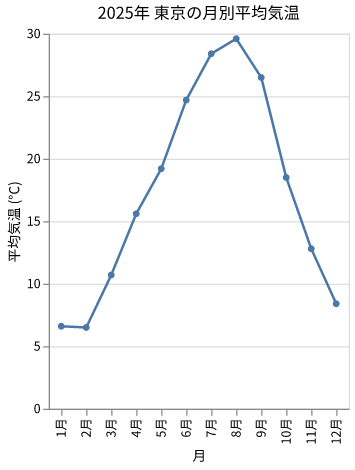